# Significance testing of PDE data

In [1]:
import MyScreeningAnalysis as msa
import os
import seaborn as sns
import numpy as np
import pandas as pd
from scipy.stats import ttest_ind
from scipy.stats import norm

### Import the data:

In [2]:
root_pth = 'G:\\SurfDrive\\Screening_Data'
inpth = os.path.join(root_pth,'2019','12','05','results')
allData = msa.loaddata(inpth)
print(allData.condition.unique())

['PDE2A' 'PDE3B' 'PDE4C' 'PDE4D' 'PDE6D' 'PDE7A' 'PDE7B' 'PDE1B' 'PDE1C'
 'PDE5A' 'PDE6G' 'PDE8A' 'PDE8B' 'PDE10A' 'PDE6A' 'PDE6B' 'PDE6C' 'PDE11A'
 'PDE4B' 'PDE4A' 'PDE1A' 'PDE3A' 'SCRAMBLED' 'LAMIN' 'RNA MIX'
 'ONLY CELLS' 'IBMX 100 μM' 'Cilostamide 1μM']


### Select wich to check

In [3]:
check = ['ONLY CELLS','RNA MIX']

### Display the distribution for the first set (it is not normal distributed):

mean for ONLY CELLS = 6.585907705372164
standard diviation for ONLY CELLS = 2.02516806244145


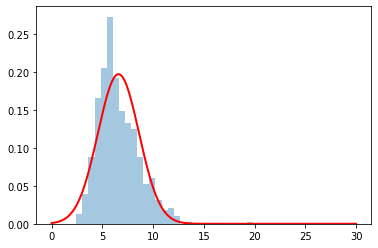

In [4]:
data0 = allData.loc[allData['condition']==check[0],'half-time(s)']
data0_N=float(data0.size)
df = pd.DataFrame(data0)
mu = df.mean().values[0]
std = df.std().values[0]
ax = sns.distplot(df,kde=False,norm_hist=True)
x = np.linspace(0,30,1000)
y = norm.pdf(x, loc=mu, scale=std) 
ax.plot(x, y, 'r', lw=2) 
print("mean for "+check[0]+" = "+str(mu))
print("standard diviation for "+check[0]+" = "+str(std))

### Try to normalize the distribution by taking the mean (the central limit theorem is on our side):

mean for ONLY CELLS = 6.590265435223204
standard diviation for ONLY CELLS = 0.6669822308125067


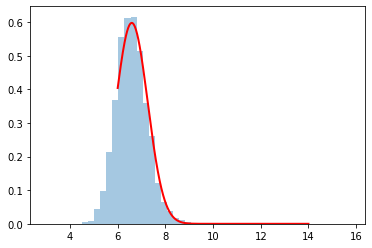

In [5]:
def normalize_data(indat):
    df = pd.DataFrame(indat)
    total = pd.DataFrame()
    for i in range(0,100): #repeat 100x
        idx = (np.arange(df.shape[0])/10).astype(int) #Use the mean of 30 randomly taken values
        np.random.shuffle(idx)
        df["Value"]= idx
        grouped = df.groupby('Value')
        grouped_mean = grouped.mean()
        total=pd.concat([total,grouped_mean])
    mu_std = [total.mean().values[0],total.std().values[0]]
    return total,mu_std

data0 = allData.loc[allData['condition']==check[0],'half-time(s)']
data0_N=data0.size
data0_total,data0_mu_std = normalize_data(data0)
ax = sns.distplot(data0_total,kde=False,norm_hist=True)
x = np.linspace(6,14,1000)
y = norm.pdf(x, loc=data0_mu_std[0], scale=data0_mu_std[1]) 
ax.plot(x, y, 'r', lw=2) 
print("mean for "+check[0]+" = "+str(data0_mu_std[0]))
print("standard diviation for "+check[0]+" = "+str(data0_mu_std[1]))

### Now for the second set

mean for RNA MIX = 6.292010173824839
standard diviation for RNA MIX = 0.8205992116401729


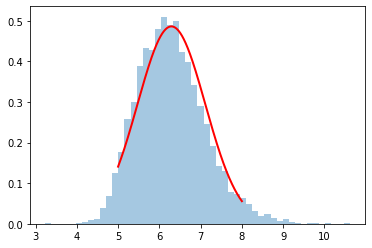

In [6]:
data1=allData.loc[allData['condition']==check[1],'half-time(s)']
data1_N=float(data1.size)
data1_total,data1_mu_std=normalize_data(data1)
ax=sns.distplot(data1_total,kde=False,norm_hist=True)
x = np.linspace(5,8,1000)
y = norm.pdf(x, loc=data1_mu_std[0], scale=data1_mu_std[1]) 
ax.plot(x, y, 'r', lw=2) 
print("mean for "+check[1]+" = "+str(data1_mu_std[0]))
print("standard diviation for "+check[1]+" = "+str(data1_mu_std[1]))

### Two reasonably normal distributions, we can do a t-test

In [7]:
ttest_ind(data0_total, data1_total)

Ttest_indResult(statistic=array([20.84622834]), pvalue=array([1.14450954e-94]))

### However, we have created datapoints by normalizing the data, artifically increasing N
Let's manually try and do a Welch's t-test with the original number of datapoints

In [8]:
v = np.sqrt(((data0_mu_std[1]**2)/data0_N)+((data1_mu_std[1]**2)/data1_N))
t = (data0_mu_std[0]-data1_mu_std[0])/v
print('t = {:.3f}'.format(t))
#find degrees of freedom
data0_v = (data0_mu_std[1]**4) / (data0_N**2 * (data0_N-1))
data1_v = (data1_mu_std[1]**4) / (data1_N**2 * (data1_N-1))
degFreedom = v**4 / (data0_v+data1_v)
print('degrees of freedom = {:.3f}'.format(degFreedom))

t = 6.295
degrees of freedom = 798.533


### OK, they are different distributions. p value is 0 (If they where the same there was a 0 chance of obtaining our results)
So to conclude: 0 is less than 0.05, so we are significant...